In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df = pd.read_csv("customer.csv")
df.head()

D:\anaconda\lib\site-packages\sklearn\linear_model\least_angle.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps,
D:\anaconda\lib\site-packages\sklearn\linear_model\least_angle.py:597: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps, copy_X=True, fit_path=True,
D:\anaconda\lib\site-pa

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore
0,37,57722.57241,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0
1,63,21328.92588,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0
2,60,150537.74250,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0
3,19,63508.76255,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0
4,54,100399.55840,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0


In [13]:
df.isnull().sum()

Age                       0
AnnualIncome              0
NumberOfPurchases         0
TimeSpentOnWebsite        0
CustomerTenureYears       0
LastPurchaseDaysAgo       0
Gender                    0
ProductCategory           0
PreferredDevice           0
Region                    0
ReferralSource            0
CustomerSegment           0
LoyaltyProgram            0
DiscountsAvailed          0
SessionCount              0
CustomerSatisfaction      0
PurchaseStatus            0
SpendingScore           540
dtype: int64

In [14]:
import math
median_SpendingScore = math.floor(df.SpendingScore.median())
median_SpendingScore

47

In [15]:
df.SpendingScore = df.SpendingScore.fillna(median_SpendingScore)
df

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore
0,37,57722.57241,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0
1,63,21328.92588,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0
2,60,150537.74250,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0
3,19,63508.76255,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0
4,54,100399.55840,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,56,113252.44120,16,26.327274,6.003410,135,Male,Kitchen,Mobile,South,Referral,Premium,1,0,1,2,0,67.0
499996,40,59758.01615,13,7.124139,-0.006796,123,Male,Kitchen,Desktop,North,Organic,Premium,1,1,3,3,0,52.0
499997,50,64968.69666,10,28.440505,0.649710,20,Male,Fashion,Mobile,North,Referral,VIP,0,4,2,2,0,37.0
499998,38,150832.32070,8,50.161579,2.903859,8,Female,Kitchen,Mobile,South,Organic,Premium,0,6,1,3,1,27.0


In [16]:
dummies = pd.get_dummies(df['Gender'], dtype=int)
dummies

,Female,Male
0,0,1
1,1,0
2,0,1
3,0,1
4,0,1
...,...,...
499995,0,1
499996,0,1
499997,0,1
499998,1,0


In [17]:
merged = pd.concat([df,dummies],axis='columns')
merged

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,Gender,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore,Female,Male
0,37,57722.57241,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0,0,1
1,63,21328.92588,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0,1,0
2,60,150537.74250,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0,0,1
3,19,63508.76255,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0,0,1
4,54,100399.55840,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,56,113252.44120,16,26.327274,6.003410,135,Male,Kitchen,Mobile,South,Referral,Premium,1,0,1,2,0,67.0,0,1
499996,40,59758.01615,13,7.124139,-0.006796,123,Male,Kitchen,Desktop,North,Organic,Premium,1,1,3,3,0,52.0,0,1
499997,50,64968.69666,10,28.440505,0.649710,20,Male,Fashion,Mobile,North,Referral,VIP,0,4,2,2,0,37.0,0,1
499998,38,150832.32070,8,50.161579,2.903859,8,Female,Kitchen,Mobile,South,Organic,Premium,0,6,1,3,1,27.0,1,0


In [18]:
df = merged.drop(['Gender','Female'],axis='columns')
df

,Age,AnnualIncome,NumberOfPurchases,TimeSpentOnWebsite,CustomerTenureYears,LastPurchaseDaysAgo,ProductCategory,PreferredDevice,Region,ReferralSource,CustomerSegment,LoyaltyProgram,DiscountsAvailed,SessionCount,CustomerSatisfaction,PurchaseStatus,SpendingScore,Male
0,37,57722.57241,19,5.908826,1.093430,11,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1,86.0,1
1,63,21328.92588,10,6.970749,0.649246,20,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0,37.0,0
2,60,150537.74250,19,35.004954,3.858211,25,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0,86.0,1
3,19,63508.76255,10,14.818000,7.554374,20,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0,37.0,1
4,54,100399.55840,19,55.925462,0.197411,92,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0,86.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,56,113252.44120,16,26.327274,6.003410,135,Kitchen,Mobile,South,Referral,Premium,1,0,1,2,0,67.0,1
499996,40,59758.01615,13,7.124139,-0.006796,123,Kitchen,Desktop,North,Organic,Premium,1,1,3,3,0,52.0,1
499997,50,64968.69666,10,28.440505,0.649710,20,Fashion,Mobile,North,Referral,VIP,0,4,2,2,0,37.0,1
499998,38,150832.32070,8,50.161579,2.903859,8,Kitchen,Mobile,South,Organic,Premium,0,6,1,3,1,27.0,0


In [19]:
df.isnull().sum()

Age                     0
AnnualIncome            0
NumberOfPurchases       0
TimeSpentOnWebsite      0
CustomerTenureYears     0
LastPurchaseDaysAgo     0
ProductCategory         0
PreferredDevice         0
Region                  0
ReferralSource          0
CustomerSegment         0
LoyaltyProgram          0
DiscountsAvailed        0
SessionCount            0
CustomerSatisfaction    0
PurchaseStatus          0
SpendingScore           0
Male                    0
dtype: int64

In [20]:
features = [
    'Age',
    'AnnualIncome',
    'NumberOfPurchases',
    'TimeSpentOnWebsite',
    'LastPurchaseDaysAgo',
    'Male',
    'SpendingScore'
]

X = df[features]

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

...

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

In [23]:
score_without = silhouette_score(X_scaled, clusters, sample_size=10000)
print("Without PCA Silhouette:", score_without)

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float


Without PCA Silhouette: 0.15607045688902854


In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [25]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance kept:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.28472246 0.14346939]
Total variance kept: 0.4281918540858768


In [26]:
kmeans_pca = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\cluster\k_means_.py:400: DeprecationWarning: `np.int

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

...

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float
D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.floa

In [27]:
score_with = silhouette_score(X_pca, clusters_pca,sample_size=10000)
print("With PCA Silhouette:", score_with)


D:\anaconda\lib\site-packages\sklearn\metrics\pairwise.py:53: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype = np.float


With PCA Silhouette: 0.34951452189292986


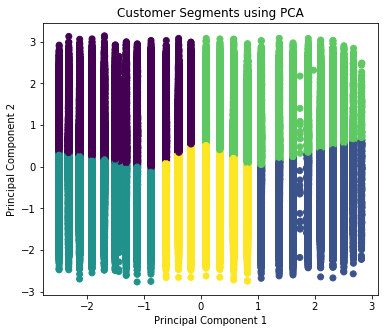

In [28]:
plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using PCA")

plt.show()

PCA reduced the dataset to two principal components while retaining most variance, enabling faster clustering and clear 2D visualization of customer segments, with clustering performance comparable to the original feature space.

In [29]:
print("Without PCA:", score_without)
print("With PCA   :", score_with)

Without PCA: 0.15607045688902854
With PCA   : 0.34951452189292986


Applying PCA improved clustering performance significantly, increasing the silhouette score from 0.156 to 0.350, indicating better cluster separation and more meaningful customer segmentation.